In [132]:
import numpy as np
import math as m

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

import matplotlib.pyplot as plt

# Two ways to read out a circuit:
#   qasm_sim  -> samples bitstrings (counts). Used by the "measure" method.
#   exact "method" doesn't need a simulator at all: Statevector(qc) gives the
#   amplitudes directly. We'll use that in the cost function for the noise-free path.
qasm_sim = AerSimulator()

## The problem

We want the **ground-state energy** of the single-qubit Hamiltonian

$$H = 3X - 2Y + 1Z$$

stored as a Pauli dictionary `H = {'X': 3, 'Y': -2, 'Z': 1}`.

The ground-state energy is the smallest eigenvalue of `H`. For a single-qubit
sum `aX + bY + cZ` the eigenvalues are exactly `±√(a² + b² + c²)`, so the exact
answer we're aiming for is

$$E_0 = -\sqrt{3^2 + (-2)^2 + 1^2} = -\sqrt{14} \approx -3.742$$

**Plan:** prepare a tunable state `|ψ(θ, φ)⟩` (the ansatz), measure its energy
`⟨H⟩(θ, φ)`, and use gradient descent to drive that energy down toward `E_0`.

In [133]:
def single_qubit_ansatz(qc, qbit_index, params):
    # params 0 is Ry, theta  and params 1 is Rz phi azimuthal
    qc.ry(params[0], qbit_index)
    qc.rz(params[1], qbit_index)
# general state form cos(θ/2)|0⟩ + e^(iφ) sin(θ/2)|1⟩

# test the method
qc = QuantumCircuit(1)
single_qubit_ansatz(qc, 0, [0, 0])
Statevector(qc)


Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [134]:
def expectation_value(params, ansatz, H, method, shots=10000):

    total = 0.0
    for pauli_str, coeff in H.items():

        if method =="exact":
            qc = QuantumCircuit(1)
            ansatz(qc, 0, params)
            psi = Statevector(qc)
            qc2 = qc.copy()
            # here we are appplying components of H 1 by 1
            if pauli_str == "X":
                qc2.x(0)
            elif pauli_str == "Y":
                qc2.y(0)
            elif pauli_str == "Z":
                qc2.z(0)
            psi2 = Statevector(qc2)

            term = np.vdot(psi.data, psi2.data).real

        elif method == "measure":
            qc = QuantumCircuit(1, 1)
            ansatz(qc, 0, params)
            if pauli_str == "X":
                qc.ry(-m.pi/2, 0)
            elif pauli_str == "Y":
                qc.rx(m.pi/2, 0)
            # Z needs no rotation
            qc.measure(0,0)
            counts = qasm_sim.run(qc, shots=shots).result().get_counts()
            # parity rule: <Pauli> = (1/shots) * sum (-1)^(#ones) * count
            term = 0
            for bitstr, n in counts.items():
                parity = (-1) ** bitstr.count("1")
                term+= parity * n
            term /= shots

        total += coeff * term # ⟨H⟩ = 3·⟨X⟩  − 2·⟨Y⟩  + 1·⟨Z⟩

    return total

# test expectation value
H = {'X': 3, 'Y':-2, 'Z': 1}
params = [1.0, 2.0]
print("exact:", expectation_value(params, single_qubit_ansatz, H, "exact"))
print("measured:", expectation_value(params, single_qubit_ansatz, H, "measure"))

exact: -2.0405189617224893
measured: -2.0042


In [135]:
def gradient_descent(init_params, cost_fn, step, eps, max_iters):
    conv_threshold = 1e-6
    params = np.array(init_params, dtype=float)
    energy = cost_fn(params)
    trajectory = [energy] # store the trajectory
    def finite_diff_grad(p):
        grad = np.zeros(len(p))
        for i in range(len(p)):
            p_plus = p.copy()
            p_plus[i] +=eps
            p_minus = p.copy()
            p_minus[i] -=eps
            grad[i] = (cost_fn(p_plus) - cost_fn(p_minus)) / (2*eps)
        return grad
    
    for _ in range(max_iters):
        grad = finite_diff_grad(params)

        #1. Step downhill based on sign of gradient
        params = params - step*grad # element wise subtract

        #2. evaluate energy
        new_energy = cost_fn(params)

        #3. record the energy
        trajectory.append(new_energy)

        #4. check for convergence
        if abs(new_energy - energy) < conv_threshold:
            break

        energy = new_energy

    return params, energy, trajectory


In [136]:
f =lambda p: expectation_value(p, single_qubit_ansatz, H, "exact")

init_params = np.array([np.random.random()*np.pi, np.random.random() * 2 * np.pi])

final_params, final_energy, trajectory = gradient_descent(init_params, f, step=0.1, eps=1e-6, max_iters=100)

# calculated E for the H
E_calc = -np.sqrt(14)

print("Exact method:")
print("total iterations", len(trajectory)-1)
print("Start energy", round(trajectory[0], 5))
print("Final energy", round(final_energy, 5))
print("Calculated energy", round(E_calc, 5))
print("error", round(abs(final_energy - E_calc), 5))
print("Final params", final_params)


f_measure = lambda p: expectation_value(p, single_qubit_ansatz, H, "measure", shots=10000)

# reuse the SAME starting point as the exact run, so the only difference is the noise
final_params_m, final_energy_m, trajectory_m = gradient_descent(
    init_params, f_measure, step=0.1, eps=0.3, max_iters=100
)

print("Noisy Measure method:")
print("Start energy", round(trajectory_m[0], 5))
print("Final energy", round(final_energy_m, 5))
print("Exact E0    ", round(E_calc, 5))
print("error       ", round(abs(final_energy_m - E_calc), 5))
print("iterations  ", len(trajectory_m) - 1)
print("Final params", final_params_m)


Exact method:
total iterations 19
Start energy 0.05638
Final energy -3.74166
Calculated energy -3.74166
error 0.0
Final params [1.84099214 2.55340577]
Noisy Measure method:
Start energy 0.0028
Final energy -3.7256
Exact E0     -3.74166
error        0.01606
iterations   30
Final params [1.8456765  2.56104753]


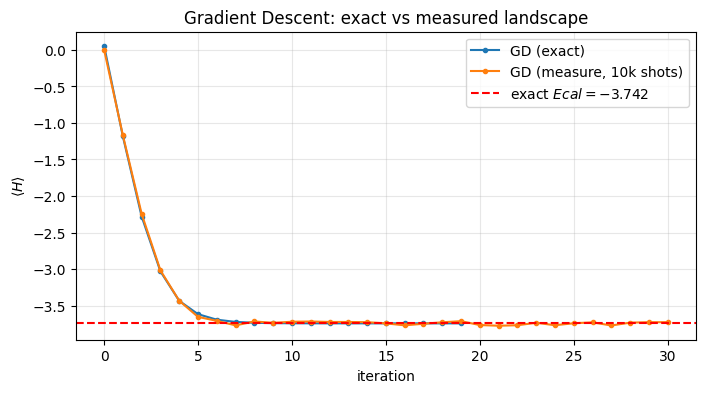

In [137]:
# plot exact vs measure on the same axes
plt.figure(figsize=(8, 4))
plt.plot(trajectory,   marker="o", markersize=3, label="GD (exact)")
plt.plot(trajectory_m, marker="o", markersize=3, label="GD (measure, 10k shots)")
plt.axhline(E_calc, color="red", linestyle="--", label=f"exact $Ecal = {E_calc:.3f}$")

plt.xlabel("iteration")
plt.ylabel(r"$\langle H \rangle$")
plt.title("Gradient Descent: exact vs measured landscape")
plt.legend()
plt.grid(alpha=0.3)
plt.show()